In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb

import shap

import warnings
warnings.filterwarnings("ignore")


print("Environment Ready")

Environment Ready


In [9]:
!wget -O creditcard.csv https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

--2026-07-22 07:47:48--  https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.64.207, 192.179.16.207, 192.178.212.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.64.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150828752 (144M) [text/csv]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>] 143.84M  61.4MB/s    in 2.3s    

2026-07-22 07:47:51 (61.4 MB/s) - ‘creditcard.csv’ saved [150828752/150828752]



In [10]:
!ls

creditcard.csv	sample_data


In [11]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.shape

(284807, 31)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [15]:
X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(227845, 30)
(56962, 30)


In [18]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(
    X_train_scaled,
    y_train
)

print("Model trained successfully")

Model trained successfully


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prediction
y_pred = model_lr.predict(X_test_scaled)

# Probability prediction
y_prob = model_lr.predict_proba(X_test_scaled)[:,1]


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[56851    13]
 [   36    62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.9605494455801453


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [21]:
model_lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr_smote.fit(
    X_train_resampled,
    y_train_resampled
)

print("SMOTE Model trained successfully")

SMOTE Model trained successfully


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_smote = model_lr_smote.predict(X_test_scaled)

y_prob_smote = model_lr_smote.predict_proba(X_test_scaled)[:,1]


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_smote))

Confusion Matrix:
[[55397  1467]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


ROC-AUC Score:
0.9708434302252134


In [23]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model_xgb.fit(
    X_train_scaled,
    y_train
)

print("XGBoost trained successfully")

XGBoost trained successfully


In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prediction
y_pred_xgb = model_xgb.predict(X_test_scaled)

# Probability
y_prob_xgb = model_xgb.predict_proba(X_test_scaled)[:,1]


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix:
[[56858     6]
 [   21    77]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.9645916716433338


In [25]:
import joblib

joblib.dump(model_xgb, "fraud_detection_xgb_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
14,V14,0.816289
7,V7,0.077267
17,V17,0.010979
4,V4,0.010036
8,V8,0.006491
10,V10,0.006125
12,V12,0.005385
29,Amount,0.004558
27,V27,0.004434
11,V11,0.004379


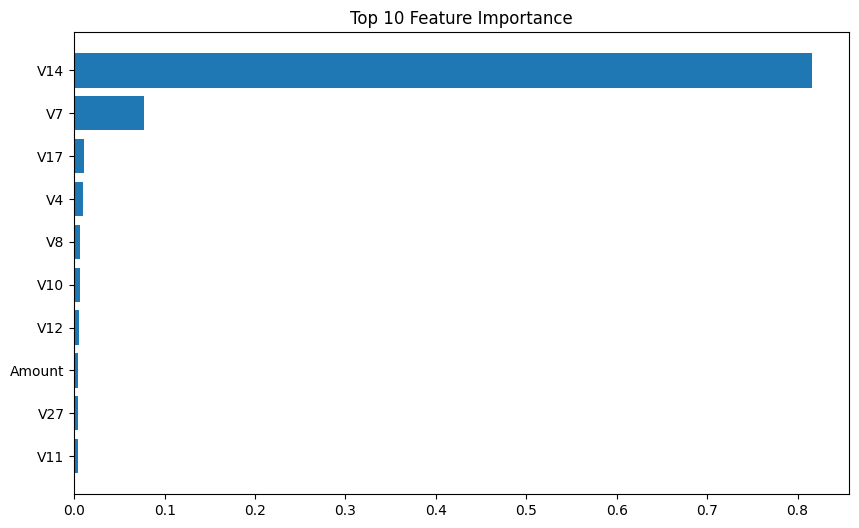

In [27]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(10)["feature"],
    feature_importance.head(10)["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")

plt.show()

In [28]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = explainer.shap_values(
    X_test_scaled
)

print("SHAP values calculated successfully")

SHAP values calculated successfully


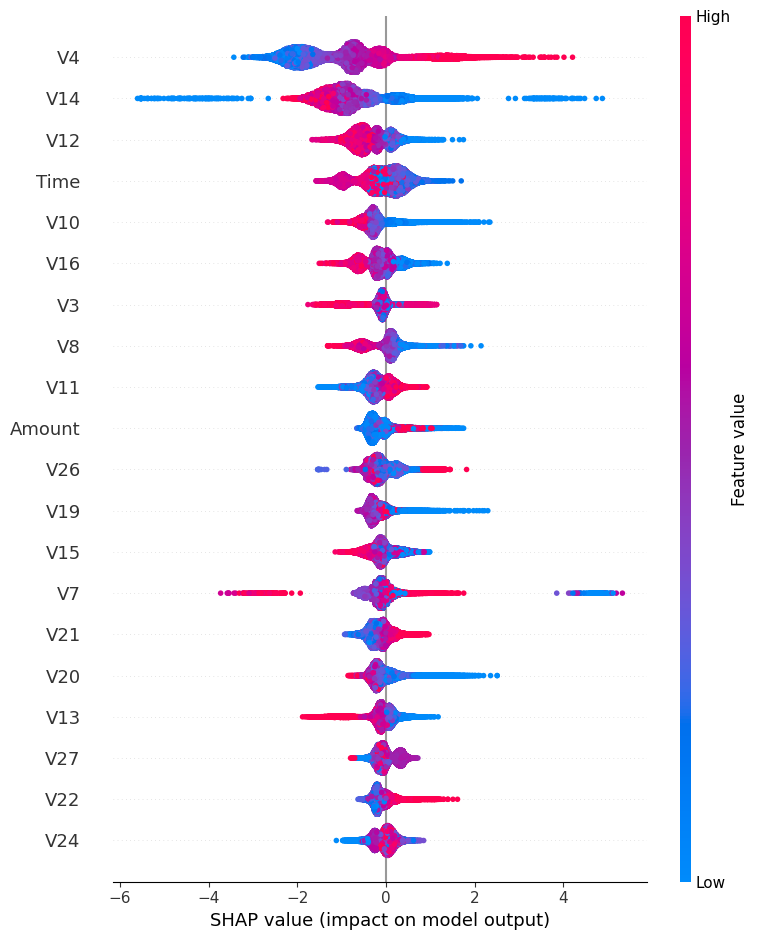

In [29]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [30]:
import numpy as np

fraud_index = np.where(y_test.values == 1)[0][0]

print("Fraud sample index:", fraud_index)

Fraud sample index: 840


In [31]:
sample = X_test_scaled[fraud_index]

prediction = model_xgb.predict(
    sample.reshape(1, -1)
)

probability = model_xgb.predict_proba(
    sample.reshape(1, -1)
)[:,1]

print("Prediction:", prediction[0])
print("Fraud Probability:", probability[0])

Prediction: 1
Fraud Probability: 0.9950295


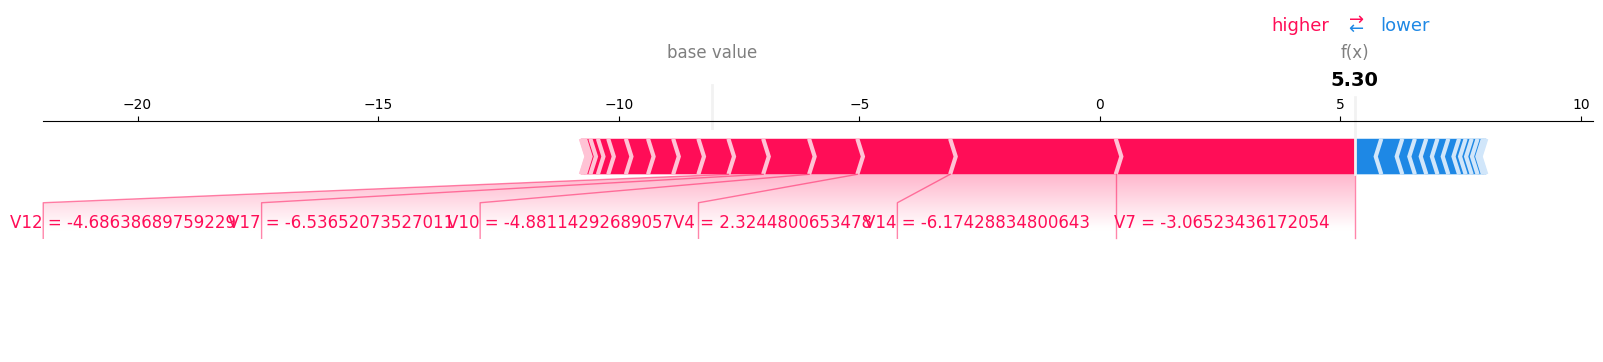

In [32]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_index],
    X_test.iloc[fraud_index],
    matplotlib=True
)

In [33]:
%%writefile predict.py

import joblib
import numpy as np


# Load model and scaler
model = joblib.load("fraud_detection_xgb_model.pkl")
scaler = joblib.load("scaler.pkl")


def predict_transaction(transaction):

    transaction = np.array(transaction).reshape(1, -1)

    transaction_scaled = scaler.transform(transaction)

    prediction = model.predict(transaction_scaled)[0]

    probability = model.predict_proba(transaction_scaled)[0][1]

    return {
        "prediction": int(prediction),
        "fraud_probability": float(probability)
    }

Writing predict.py


In [34]:
!ls

creditcard.csv		       predict.py   scaler.pkl
fraud_detection_xgb_model.pkl  sample_data


In [35]:
from predict import predict_transaction

sample_transaction = X_test.iloc[0].values

result = predict_transaction(sample_transaction)

result

{'prediction': 0, 'fraud_probability': 1.5042564882605802e-06}

In [36]:
!mkdir -p fraud-detection-explainable-ai/{data,models,notebooks,src}

In [37]:
!find fraud-detection-explainable-ai -maxdepth 2 -type d

fraud-detection-explainable-ai
fraud-detection-explainable-ai/src
fraud-detection-explainable-ai/data
fraud-detection-explainable-ai/models
fraud-detection-explainable-ai/notebooks


In [38]:
!mv creditcard.csv fraud-detection-explainable-ai/data/

!mv fraud_detection_xgb_model.pkl scaler.pkl fraud-detection-explainable-ai/models/

!mv predict.py fraud-detection-explainable-ai/src/

In [39]:
!find fraud-detection-explainable-ai -maxdepth 2 -type f

fraud-detection-explainable-ai/src/predict.py
fraud-detection-explainable-ai/data/creditcard.csv
fraud-detection-explainable-ai/models/scaler.pkl
fraud-detection-explainable-ai/models/fraud_detection_xgb_model.pkl


In [40]:
%%writefile fraud-detection-explainable-ai/requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
imbalanced-learn
shap
joblib

Writing fraud-detection-explainable-ai/requirements.txt


In [41]:
!ls fraud-detection-explainable-ai

data  models  notebooks  requirements.txt  src


In [42]:
%%writefile fraud-detection-explainable-ai/README.md

# Fraud Detection with Explainable AI

## Overview

A Machine Learning project for detecting fraudulent credit card transactions using supervised learning models and Explainable AI techniques.

The goal of this project is not only to predict fraudulent transactions but also to explain why the model makes each decision.

## Project Pipeline

Data Loading
↓
Data Preprocessing
↓
Train/Test Split
↓
Feature Scaling
↓
Handling Class Imbalance (SMOTE)
↓
Model Training
↓
Evaluation
↓
Explainability with SHAP


## Models Used

- Logistic Regression
- Logistic Regression + SMOTE
- XGBoost Classifier


## Results

Best Model: XGBoost

ROC-AUC Score: 0.9646

Fraud Detection Performance:

- Precision: 0.93
- Recall: 0.79
- F1-score: 0.85


## Explainable AI

SHAP (SHapley Additive exPlanations) was used to understand model decisions.

The project provides:

- Global Feature Importance
- SHAP Summary Plot
- Local Explanation for Individual Transactions


## Project Structure


Writing fraud-detection-explainable-ai/README.md


In [43]:
!ls fraud-detection-explainable-ai

data  models  notebooks  README.md  requirements.txt  src
